In [91]:
import sys
print(sys.executable)

/Applications/Xcode.app/Contents/Developer/usr/bin/python3


In [92]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install numpy matplotlib qutip

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [93]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

print(np.__version__)
print(qt.__version__)

2.0.2
5.0.4


In [94]:
# Constants

gamma_e = 1.760859e11  # gyromagnetic ratio of the electron, rad/s/T
B0 = 47e-6 # geomagnetic field strength, T

# a_hf_time = 1 microsecond means hyperfine interaction time = 1/a
a_hf_time = 1.0e-6 # seconds
A0 = 1 / a_hf_time # rad/s

# Anisotropic hyperfine tensor
# Borrowed from Bandyopadhyay 
A_tensor_default = np.diag([A0, A0, 2*A0]) # rad/s

# Single-spin operators

# identity matrix makes this similar to identity property
I2 = qt.qeye(2)

sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()   

# Stern-gerlach experiment measured that the spin component along any axis is 
# quantized in units of hbar/2.
Sx = 0.5 * sx
Sy = 0.5 * sy
Sz = 0.5 * sz

In [95]:
# 8D Hilbert Space
# Must have 3 parts because of 8D space
# Sx, Sy, and Sz represent spin components 
# 

# Electron 1 spin operators
S1x = qt.tensor(Sx, I2, I2)
S1y = qt.tensor(Sy, I2, I2)
S1z = qt.tensor(Sz, I2, I2)

# Electron 2 spin operators
S2x = qt.tensor(I2, Sx, I2)
S2y = qt.tensor(I2, Sy, I2)
S2z = qt.tensor(I2, Sz, I2)

# Nuclear spin operators
Ix = qt.tensor(I2, I2, Sx)
Iy = qt.tensor(I2, I2, Sy)
Iz = qt.tensor(I2, I2, Sz)

# Full identity operators 
I8 = qt.tensor(I2, I2, I2)

print("Hilbert space dimension:", I8.shape)

Hilbert space dimension: (8, 8)


In [96]:
# Basis states

# Makes a 2D vector with 1 in the position index and 0 everywhere else
up = qt.basis(2,0)
down = qt.basis(2,1)

# Electron singlet state
singlet_e = (qt.tensor(up, down) - qt.tensor(down, up)).unit()

#singlet projector for two electrons only
P_S_e = singlet_e * singlet_e.dag()

# singlet projector for the full system (electrons + nucleus)
P_S = qt.tensor(P_S_e, I2)

P_T = I8 - P_S

print("Full singlet projector shape:", P_S.shape)

Full singlet projector shape: (8, 8)


In [97]:
# to find the probability of something we do 
# qt.expect(P, state)

singlet_prob_e = qt.expect(P_S_e, singlet_e)

print("Singlet probability for electron:", singlet_prob_e)

Singlet probability for electron: 0.9999999999999997


In [98]:
# Initial density matrix

# Electron singlet density matrix
rho_e = P_S_e

# unpolarized nuclear spin state - 50% up or down
rho_n = 0.5 * I2

# Full initial density matrix (electron singlet + mixed nucleus)
rho0 = qt.tensor(rho_e, rho_n)

print("Initial density matrix shape:", rho0.shape)
# measures the trace of the matrix, which should be 1 for a valid density matrix
print("Trace of rho0:", rho0.tr())

# testing singlet probability after adding mixed nucleus
singlet_prob_full = qt.expect(P_S, rho0)

print("Singlet probability for full system:", singlet_prob_full)



Initial density matrix shape: (8, 8)
Trace of rho0: 0.9999999999999998
Singlet probability for full system: 0.9999999999999998


In [99]:
def magnetic_field_vector(theta_deg, B_strength=B0, phi_deg=0):
    """
    Return magnetic field vector B = (Bx, By, Bz) in Tesla.
    
    theta_deg: inclination angle from molecular z-axis
    phi_deg: azimuthal angle around z-axis

    for simplicity in this model, keep phi = 0.
    """

    # converts degrees to radians for the trig
    theta = np.deg2rad(theta_deg)
    phi = np.deg2rad(phi_deg)

    Bx = B_strength * np.sin(theta) * np.cos(phi)
    By = B_strength * np.sin(theta) * np.sin(phi)
    Bz = B_strength * np.cos(theta)

    return np.array([Bx, By, Bz])

In [100]:
def build_zeeman_hamiltonian(theta_deg, B_strength=B0, phi_deg=0):
    """
    Zeeman Hamiltonian for both electrons in the same magnetic field.
    Units: rad/s
    """

    Bx, By, Bz = magnetic_field_vector(theta_deg, B_strength, phi_deg)

    #expanding the dot product of B and S
    # ex: a*b = axbx + ayby + azbz
    HZ = gamma_e * (
    Bx * (S1x + S2x) 
    + By * (S1y + S2y)
    + Bz * (S1z + S2z)
    )

    return HZ

In [101]:
# for now, just one anisotropic hyperfine coupling to the first electron

def build_hyperfine_hamiltonian(A_tensor):
    """ 
    Hyperfine Hamiltonian for Electron 1 coupled to one nucleus.

    General form:
        H_HF = sum_{i,j} S1_i A_ij I_j

    did this because I has Ix, Iy, and Iz
    S1 has S1x, S1y, and S1z
    A has Axx, Axy, Axz, etc.

    """

    S1_ops = [S1x, S1y, S1z]
    I_ops = [Ix, Iy, Iz]

    Hhf = 0 * I8

    for i in range(3):
        for j in range(3):
            Hhf += A_tensor[i, j] * S1_ops[i] * I_ops[j]

    return Hhf

In [102]:
def build_total_hamiltonian(
        theta_deg,
        B_strength=B0,
        A_tensor=None,
        include_zeeman=True,
        include_hyperfine=True,
):
    """
    Total Hamiltonian:
        H = H_Zeeman + H_Hyperfine
    """

    H = 0 * I8

    if include_zeeman:
        H += build_zeeman_hamiltonian(theta_deg, B_strength)

    if include_hyperfine:
        if A_tensor is None:
            A_tensor = A_tensor_default
        H += build_hyperfine_hamiltonian(A_tensor)

    return H

In [103]:
def evolve_singlet_probability(H, rho_initial, tlist):
    """
    Evolves rho under Hamiltonian H and returns singlet probability over time.

    This is evolution only, no recombination or decoherence.
    """
    #mesolve(Hamiltonian, initial state, time list, collapse operators, expectation operators)
    #collapse operators not there = no decoherence
    result = qt.mesolve(H, rho_initial, tlist, c_ops=[], e_ops=[P_S])

    return np.array(result.expect[0])

Initial singlet probability: 0.9999999999999999
Final singlet probability: 0.9999999999999999
Minimum singlet probability: 0.9999999999999999
Maximum singlet probability: 0.9999999999999999


Text(0.5, 1.0, 'Zeeman only: singlet probability should stay near 1')

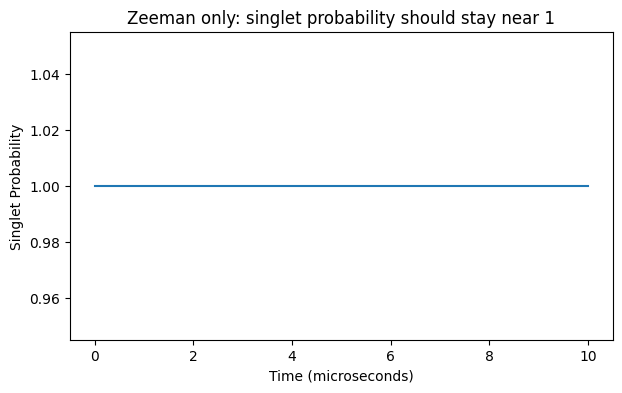

In [104]:
# Time grid: 0 to 10 microseconds
tlist = np.linspace(0, 10e-6, 1000)

theta_test = 45  

H_no_hf = build_total_hamiltonian(
    theta_deg = theta_test, 
    include_zeeman=True,
    include_hyperfine=False
)

P_s_no_hf = evolve_singlet_probability(H_no_hf, rho0, tlist)

print("Initial singlet probability:", P_s_no_hf[0])
print("Final singlet probability:", P_s_no_hf[-1])
print("Minimum singlet probability:", (P_s_no_hf).min())
print("Maximum singlet probability:", (P_s_no_hf).max())

plt.figure(figsize = (7, 4))
plt.plot(tlist * 1e6, P_s_no_hf, label='No Hyperfine')
plt.xlabel('Time (microseconds)')
plt.ylabel('Singlet Probability')
plt.title("Zeeman only: singlet probability should stay near 1")

Initial singlet probability: 0.9999999999999999
Final singlet probability: 0.4779619453982751
Minimum singlet probability: 0.011791746774270417
Maximum singlet probability: 0.9999999999999999


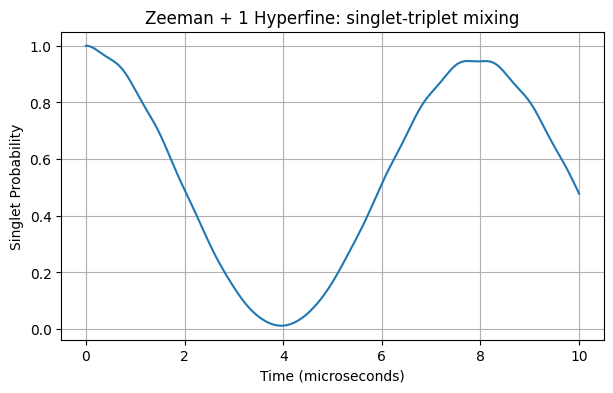

In [105]:
H_with_hf = build_total_hamiltonian(
    theta_deg = theta_test,
    include_zeeman=True,
    include_hyperfine=True,
    A_tensor = A_tensor_default
)

P_s_with_hf = evolve_singlet_probability(H_with_hf, rho0, tlist)

print("Initial singlet probability:", P_s_with_hf[0])
print("Final singlet probability:", P_s_with_hf[-1])
print("Minimum singlet probability:", (P_s_with_hf).min())
print("Maximum singlet probability:", (P_s_with_hf).max())

plt.figure(figsize = (7, 4))
plt.plot(tlist * 1e6, P_s_with_hf, label='With Hyperfine')
plt.xlabel('Time (microseconds)')
plt.ylabel('Singlet Probability')
plt.title("Zeeman + 1 Hyperfine: singlet-triplet mixing")
plt.grid(True)
plt.show()

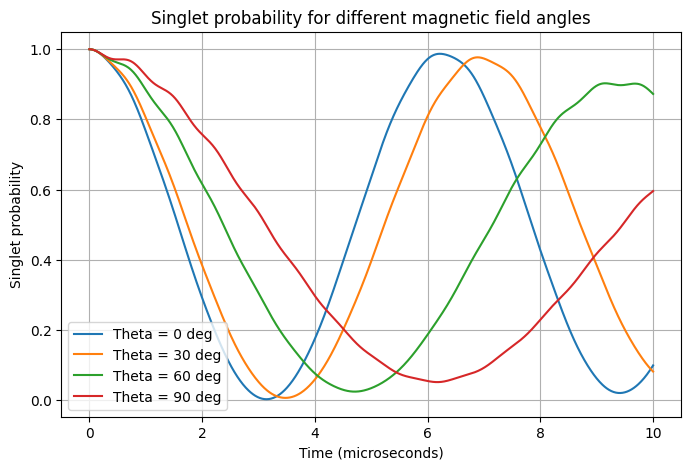

In [106]:
theta_values = [0, 30, 60, 90]

plt.figure(figsize=(8, 5))

for theta in theta_values:
    H_theta = build_total_hamiltonian(
        theta_deg = theta,
        include_zeeman=True,
        include_hyperfine=True,
        A_tensor = A_tensor_default
    )

    P_s_theta = evolve_singlet_probability(H_theta, rho0, tlist)

    plt.plot(tlist * 1e6, P_s_theta, label=f"Theta = {theta} deg")

plt.xlabel('Time (microseconds)')
plt.ylabel("Singlet probability")
plt.title("Singlet probability for different magnetic field angles")
plt.legend()
plt.grid(True)
plt.show()